<a href="https://colab.research.google.com/github/tlmakinen/degeneracy_distillery/blob/main/tutorial_notebooks/imrphenomd_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gravitational Waves — IMRPhenomD inspiral-merger-ringdown

Same Distillery pipeline as `gw_example.ipynb`, but using a full
**IMRPhenomD** waveform from `pycbc` / `lalsuite` (non-spinning).  The
IMRPhenomD includes the merger and ringdown effects in the merger inspiral.


>Here, chirp mass no longer dominates. Let's see what physical coordinates (functions of $m_1,m_2$) control the waveform signal.

**note:** The outputs here will vary depending on device used. It is not intended to be representative of published results.


In [ ]:
!git clone https://github.com/tlmakinen/degeneracy_distillery.git
%cd /content/degeneracy_distillery
!pip install -q -e .
%cd /content/
!git clone https://github.com/DeaglanBartlett/ESR.git
%cd /content/ESR
!pip install -q -e .
# pycbc pulls lalsuite which provides IMRPhenomD via SWIG
!pip install -q pycbc


**Restart the runtime** before continuing on Colab.

In [ ]:
import os
# os.kill(os.getpid(), 9)


In [1]:
import esr.generation.generator
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
try:
    from pycbc.waveform import get_fd_waveform
except ImportError as exc:
    raise SystemExit("pycbc is required for this notebook (`pip install -q pycbc`).") from exc

import numpy as np
import jax, jax.numpy as jnp, jax.random as jr
import matplotlib.pyplot as plt
import sympy
from tqdm import tqdm
from sklearn.decomposition import PCA
import flax.linen as nn

from degeneracy_distillery.training_loop_fishnets import train_fishnets
from degeneracy_distillery.training_loop_flatten import fit_flattening
from degeneracy_distillery.align_coords import load_and_process_data_v2
from degeneracy_distillery.sr_utils import (
    fit_and_analyze_sr, analyze_equations, sr_structure_predicate,
    check_symbolic_invertibility,
    fit_theta_scaler, expressions_to_physical,
)
from degeneracy_distillery.postprocess_new import (
    analyze_atom_sharing, regroup_like_terms,
)
from degeneracy_distillery.postprocessing_utils import (
    print_discovered_expressions, get_y_sr,
    flatten_with_numerical_jacobian, check_flattening,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'figure.figsize': (8, 5),
    'figure.dpi': 130, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})


## 1. IMRPhenomD waveform simulator + PCA

In [2]:
key = jr.PRNGKey(42)

M_SUN_SEC = 4.925491025543576e-6
M1_MIN, M1_MAX = 5.0, 50.0
M2_MIN, M2_MAX = 5.0, 50.0
D_L_MPC = 200.0
F_LOW, F_HIGH, DF = 20.0, 2048.0, 0.5  # extends past TaylorF2 f_ISCO so f_RD is resolved
N_PCA = 40
APPROX = "IMRPhenomD"
nsims = 1000


def chirp_mass(m1, m2):           return (m1 * m2) ** (3 / 5) / (m1 + m2) ** (1 / 5)
def symmetric_mass_ratio(m1, m2): return (m1 * m2) / (m1 + m2) ** 2


def aLIGO_psd(f):
    f = np.asarray(f, dtype=float)
    x = f / 215.0
    psd = 1e-49 * (x ** -4.14 + 2.0 + 2.0 * x ** 2)
    return np.where(f >= 10.0, psd, np.inf)


freqs  = np.arange(F_LOW, F_HIGH, DF)
psd    = aLIGO_psd(freqs)
whiten = np.sqrt(4.0 * DF) / np.sqrt(psd)
n_freq = len(freqs)
I_START = int(round(F_LOW / DF))   # offset on pycbc's [0, df, 2df, ...] grid
print(f"frequency grid: {F_LOW}–{freqs[-1]:.0f} Hz, {n_freq} bins")


def imrphenomd_waveform(m1, m2, freqs, d_L_Mpc=D_L_MPC):
    """IMRPhenomD h_+ on the common `freqs` grid.

    pycbc requires mass1 >= mass2; IMRPhenomD is symmetric under m1 <-> m2 for
    aligned spins (here both zero), so we just swap internally if needed.
    """
    m_large, m_small = (float(m1), float(m2)) if m1 >= m2 else (float(m2), float(m1))
    hp, _ = get_fd_waveform(
        approximant=APPROX,
        mass1=m_large, mass2=m_small,
        spin1z=0.0, spin2z=0.0,
        delta_f=DF,
        f_lower=F_LOW, f_final=F_HIGH,
        distance=d_L_Mpc,
    )
    h_full = np.asarray(hp.data, dtype=complex)
    h = np.zeros(n_freq, dtype=complex)
    end = min(I_START + n_freq, h_full.size)
    h[: end - I_START] = h_full[I_START:end]
    return h


# masses on the full square (no m1>=m2 cut)
key, sub = jr.split(key)
m1_all = np.random.uniform(M1_MIN, M1_MAX, 2 * nsims)
m2_all = np.random.uniform(M2_MIN, M2_MAX, 2 * nsims)
theta_all = np.stack([m1_all, m2_all], axis=1).astype(np.float32)

print("building PCA basis...")
basis_idx = np.random.default_rng(0).choice(2 * nsims, min(2 * nsims, 5000), replace=False)
bank = np.empty((len(basis_idx), 2 * n_freq))
for j, i in enumerate(tqdm(basis_idx, desc="bank")):
    h = imrphenomd_waveform(m1_all[i], m2_all[i], freqs) * whiten
    bank[j] = np.concatenate([h.real, h.imag])
pca = PCA(n_components=N_PCA).fit(bank)
print(f"PCA: {N_PCA} components capture {pca.explained_variance_ratio_.cumsum()[-1] * 100:.1f}% var")

print("generating noisy waveforms...")
keys = jr.split(sub, 2 * nsims)
data_all = np.empty((2 * nsims, N_PCA), dtype=np.float32)
for i in tqdm(range(2 * nsims), desc="IMRPhenomD"):
    h = imrphenomd_waveform(theta_all[i, 0], theta_all[i, 1], freqs) * whiten
    hvec = np.concatenate([h.real, h.imag])
    noise = np.array(jr.normal(keys[i], shape=hvec.shape))
    data_all[i] = pca.transform((hvec + noise).reshape(1, -1)).flatten()

theta_train, data_train = theta_all[:nsims], data_all[:nsims]
theta_test,  data_test  = theta_all[nsims:], data_all[nsims:]
print("theta_train", theta_train.shape, "data_train", data_train.shape)


frequency grid: 20.0–2048 Hz, 4056 bins
building PCA basis...


bank: 100%|██████████| 2000/2000 [02:27<00:00, 13.60it/s]


PCA: 40 components capture 99.4% var
generating noisy waveforms...


IMRPhenomD: 100%|██████████| 2000/2000 [02:27<00:00, 13.56it/s]

theta_train (1000, 2) data_train (1000, 40)


## 2. Pre-fishnet rescaling

In [3]:
scaler = fit_theta_scaler(theta_train, feature_range=(1.0, 2.0))
theta_train_s = scaler.transform(theta_train).astype(np.float32)
theta_test_s  = scaler.transform(theta_test).astype(np.float32)
print("scaled range:", theta_train_s.min(0), theta_train_s.max(0))


scaled range: [1. 1.] [2. 2.]


## 3. Fisher-network ensemble

In [4]:
embedding_net = nn.Sequential([
    nn.Dense(128), nn.gelu,
    nn.Dense(64),  nn.gelu,
    nn.Dense(64),  nn.gelu,
])

_ = train_fishnets(
    theta_train_s, data_train,
    theta_test_s,  data_test,
    num_models=20, train_epochs=5000,
    hids_min=50, hids_max=300, patience=30, n_layers=[3, 5],
    embedding_net=embedding_net,
    lr=5e-5, train_batch_size=200,
    outdir="fishnets-imr",
)


saving to fishnets-imr
data_test shape: (1000, 40)
theta_test shape: (1000, 2)
Chosen hidden size for model 1 : 89 | layers: 4
Chosen hidden size for model 2 : 120 | layers: 5
Chosen hidden size for model 3 : 276 | layers: 5
Chosen hidden size for model 4 : 139 | layers: 3
Chosen hidden size for model 5 : 225 | layers: 4
Chosen hidden size for model 6 : 263 | layers: 4
Chosen hidden size for model 7 : 164 | layers: 3
Chosen hidden size for model 8 : 95 | layers: 5
Chosen hidden size for model 9 : 119 | layers: 4
Chosen hidden size for model 10 : 191 | layers: 3
Chosen hidden size for model 11 : 204 | layers: 4
Chosen hidden size for model 12 : 78 | layers: 3
Chosen hidden size for model 13 : 100 | layers: 3
Chosen hidden size for model 14 : 254 | layers: 3
Chosen hidden size for model 15 : 269 | layers: 5
Chosen hidden size for model 16 : 221 | layers: 3
Chosen hidden size for model 17 : 253 | layers: 5
Chosen hidden size for model 18 : 215 | layers: 3
Chosen hidden size for model 19 :

Epoch 365 loss: -4.64142 ; val_loss: -2.07186:   7%|▋         | 365/5000 [00:49<10:28,  7.38it/s]



Early stopping triggered at epoch 365

Training model 2 of 20


Epoch 344 loss: -4.60021 ; val_loss: -1.94776:   7%|▋         | 344/5000 [00:31<07:03, 11.00it/s]



Early stopping triggered at epoch 344

Training model 3 of 20


...


Early stopping triggered at epoch 1439

Training model 19 of 20


Epoch 392 loss: -4.50022 ; val_loss: -2.34314:   8%|▊         | 392/5000 [00:36<07:08, 10.75it/s]



Early stopping triggered at epoch 392

Training model 20 of 20


Epoch 1633 loss: -4.51216 ; val_loss: -2.86374:  33%|███▎      | 1633/5000 [00:50<01:44, 32.22it/s]



Early stopping triggered at epoch 1633
Ensemble weights: [13.50276  14.653361 17.372513 11.572814 16.745539 14.971035 10.879109
 23.186907 14.565343 14.72062  20.569181 18.495403 14.686739 17.076159
 18.525751 15.47243  20.82586  13.69171  14.748555 18.13729 ]
Training completed. Outputs saved to: fishnets-imr/fishnets_outputs.npz
Note: Load with io_utils.load_fishnets_results(file) for alias support


## 4. Flattening Network

We use the same Log-Euclidean median across ensemble members for `F_avg` as
the TaylorF2 example, plus the Procrustes / sign-permute alignment options.

In [29]:
fish = np.load("fishnets-imr/fishnets_outputs.npz")
thetas = jnp.array(fish["theta"])
ensemble_weights = fish["ensemble_weights"]
F_network_ensemble = jnp.array(fish["Fs"])

# keep top-10 ensemble members for speed
topn = 10
best = np.argsort(ensemble_weights)[-topn:]
ensemble_weights = ensemble_weights[best]
F_network_ensemble = F_network_ensemble[best]


def _matrix_log_psd(M, eps=1e-12):
    M_sym = 0.5 * (M + jnp.swapaxes(M, -1, -2))
    evals, evecs = jnp.linalg.eigh(M_sym)
    log_e = jnp.log(jnp.maximum(evals, eps))
    return (evecs * log_e[..., None, :]) @ jnp.swapaxes(evecs, -1, -2)


def _matrix_exp_sym(M):
    M_sym = 0.5 * (M + jnp.swapaxes(M, -1, -2))
    evals, evecs = jnp.linalg.eigh(M_sym)
    return (evecs * jnp.exp(evals)[..., None, :]) @ jnp.swapaxes(evecs, -1, -2)


log_F_ens = jax.vmap(jax.vmap(_matrix_log_psd))(F_network_ensemble)
F_avg_LE  = jax.vmap(_matrix_exp_sym)(jnp.median(log_F_ens, axis=0))

w, ensemble_w, outputs_flatten, flatten_model = fit_flattening(
    F_network_ensemble, thetas,
    F_avg=F_avg_LE,
    ensemble_weights=ensemble_weights,
    hidden_size=100, n_layers=5,
    batch_size=250,
    epochs_phase1=2000, epochs_phase2=2500, finetune_epochs=500,
    min_epochs=1200, patience=50,
    lr_phase1=1e-5, lr_schedule_initial=1e-3, lr_decay=0.3, lr_finetune=2e-6,
    norm_factor=None, norm_method="median_max_eig",
    noise=1e-8, seed=0,
    flattener_activation="softplus",
    Fisher_to_flatten="average",
    output_prefix="imr_flatten",
    use_whitening=True, nn_inv=False,
    forward_backward_mlp=False,
    forward_backward_invertibility_weight=1.0,
    minmax_scale_inputs=True,
    grad_clip_norm=1.0,
    loss_type="log_frob",
    beta_det=0.1,
    augment_log_inputs=True,
    l1_alpha=0.0, do_plot=False,
    return_model=True,
)


COMPUTING ROBUST NORM FACTOR (method: median_max_eig)
norm_factor = 478.495
COMPUTING WHITENING TRANSFORM
Global mean Fisher shape: (2, 2)
Global mean Fisher:
[[0.5361025  0.49684274]
 [0.49684274 0.5262178 ]]
Mean Fisher eigenvalues: [0.03429285 1.0280275 ]
W_inv transformation:  [[0.6036718  0.41434634]
 [0.41434634 0.59542847]]
Whitened Fisher global mean (should be ~I):
[[0.99999964 0.        ]
 [0.         0.9999998 ]]
W_inv condition number: 5.48
Flattener activation: softplus
Loss type: log_frob
Min-max input scaling: True
Min-max post-scale offset: 0.1
Log input augmentation: ON (+3 features)
USING WHITENED MLP (with inverse whitening layer)
TRAINING FLATTENER NET
FINE-TUNING FLATTENER NET

 patience reached. stopping training.
FINE-TUNING EACH ENSEMBLE MEMBER
fine-tuning for ensemble member 0
fine-tuning for ensemble member 1
fine-tuning for ensemble member 2
fine-tuning for ensemble member 3
fine-tuning for ensemble member 4
fine-tuning for ensemble member 5
fine-tuning for e

## 5. Coordinate alignment

In [30]:
data = load_and_process_data_v2(
    datapath="./",
    filename="imr_flatten.npz",
    num_samps=4000, seed=44,
    process_ensemble=True, n_d=1.0,
    align_mode="procrustes",
    separate_nonlinearity=True,
    canonicalize="permute_and_sign",
    use_prior_normalization=True,
    restore_reference_mean=True,
    Fisher_to_flatten="best",
    verbose=False,
)

X = data["X"]
mask = X[:, 1] > 0.0
X, y, y_std, dy_sr, Fs = X[mask], data["y"][mask], data["y_std"][mask], data["dy_sr"][mask], data["Fs"][mask]
n_params = X.shape[1]
print("aligned X", X.shape, "y", y.shape)


aligned X (1000, 2) y (1000, 2)


### data augmentation for symbolic regression
We have a model for $\theta \rightarrow \eta$. Now we are free to generate loads of examples of $X=\theta$ and corresponding outputs $y=\eta$ to fit SR to.

In [31]:
from degeneracy_distillery.postprocessing_utils import weighted_std

X_sr = jr.uniform(key, minval=X.min(0), maxval=X.max(0), shape=(2000, n_params))

ys_sr = jnp.array([jax.vmap(lambda x: flatten_model.apply(w_i, x))(X_sr) for w_i in ensemble_w])

ys_sr_rot = np.array([
    np.einsum("ij,bj->bi", data['rotmats'][i], ys_sr[i] - ys_sr[i].mean(0))
    for i in range(len(ys_sr))
])

y_std_sr = weighted_std(ys_sr_rot, data['ensemble_weights'])
y_sr = np.average(ys_sr_rot, 0, data['ensemble_weights'])
ys_sr_rot -= y_sr.min(0)
y_sr -= y_sr.min(0)

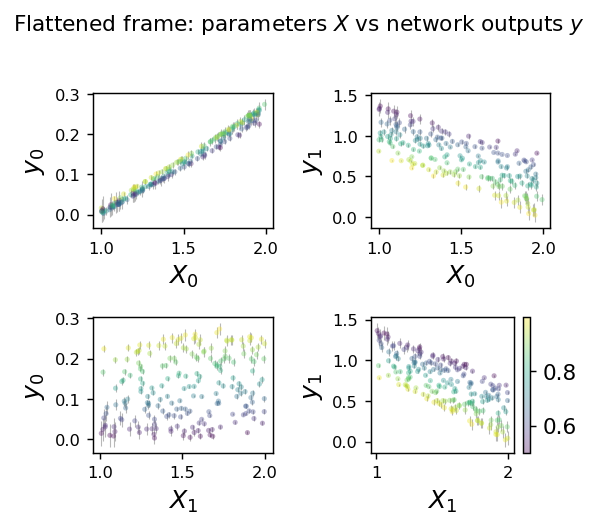

In [32]:
#@title visualise coordinates
def plot_flattened_X_vs_y(X, y, y_std, skip=10, save_path=None):
    """Grid of X_i vs y_j with +/-1 sigma error bars on y (subsampled)."""
    X = np.asarray(X)
    y = np.asarray(y)
    y_std = np.asarray(y_std)
    nx, ny = X.shape[1], y.shape[1]
    fig, axs = plt.subplots(nx, ny, figsize=(2.3 * ny, 2.0 * nx), squeeze=False)
    sub = slice(None, None, skip)
    for i in range(nx):
        for j in range(ny):
            ax = axs[i, j]
            ax.errorbar(
                X[sub, i], y[sub, j], yerr=y_std[sub, j],
                fmt="none", ecolor="0.72", elinewidth=0.6, capsize=0, zorder=1,
            )
            cs = ax.scatter(
                X[sub, i], y[sub, j],
                s=8, c=X[sub, i-1] / X[:, i-1].max(),
                alpha=0.35, linewidths=0, zorder=2,
            )
            ax.set_xlabel(rf"$X_{{{i}}}$")
            ax.set_ylabel(rf"$y_{{{j}}}$")
            ax.tick_params(labelsize=9)
    fig.suptitle(
        r"Flattened frame: parameters $X$ vs network outputs $y$",
        fontsize=12, y=1.01,
    )
    plt.colorbar(cs)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_flattened_X_vs_y(X_sr, y_sr, y_std_sr, skip=10, save_path="X_vs_y_grid_imrphenom.pdf")

## 6. Symbolic regression

In [33]:
from degeneracy_distillery.sr_utils import fit_symbolic_regression

fit_symbolic_regression(
    X_sr, y_sr, y_std_sr,
    parent_dir="./sr_results_imr/",
    random_state=123,
    time_limit=60 * 2,
    max_length=30, max_depth=20,
    allowed_symbols="add,mul,div,pow,constant,variable,exp",
    objectives=["r2", "length"],
)



Fitting component 1 of 2 (index 0)
X train shape: (2000, 2), y train shape: (2000,)
Fitting...
Done!
Best model: ((-0.25) + (2.75 * (0.09 * X1)))
Stats: {'model_length': 5, 'model_complexity': 7, 'generations': 484, 'evaluation_count': 0, 'residual_evaluations': 4363439, 'jacobian_evaluations': 2760677, 'random_state': 123}
Outputting 20 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 2 of 2 (index 1)
X train shape: (2000, 2), y train shape: (2000,)
Fitting...
Done!
Best model: (2.81 + ((-2.50) * ((0.28 * X2) + (0.27 * X1))))
Stats: {'model_length': 7, 'model_complexity': 11, 'generations': 578, 'evaluation_count': 0, 'residual_evaluations': 4822413, 'jacobian_evaluations': 3075476, 'random_state': 123}
Outputting 20 individuals on Pareto front
Outputting 2000 individuals in population


In [34]:
X_test, y_test, y_std_test = X, y, y_std
dy_sr_test, Fs_test = dy_sr, Fs

mdl_coords, frob_coords, analysis = analyze_equations(
    X_test, y_test, y_std_test, dy_sr_test, Fs_test,
    parent_dir="sr_results_imr/",
    n_params=n_params,
    equation_set="pareto",
    max_complexity_thresh=20,
    length_penalty=2.0,
    equation_predicate=sr_structure_predicate(
        n_params=n_params,
        check_nested_exp=True, max_exp_nesting=1,
        forbid_self_transcendental=True,
    ),
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in mdl_coords])



Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
12 equations below complexity threshold 20
3 / 12 equations pass equation_predicate (skipped 9)

Best MDL equation (complexity=8):
  ((-0.250710) + (3.475498 * (exp((0.080109 * X2)) * (0.064771 * X1))))
  LaTeX: $X_{1} b_{1} b_{3} e^{X_{2} b_{2}} + b_{0}$

Best Frob loss equation (complexity=6):
  ((-1.353467) + (1.145033 * exp((0.171984 * X1))))
  LaTeX: $b_{0} + b_{1} e^{X_{1} b_{2}}$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
11 equations below complexity threshold 20
4 / 11 equations pass equation_predicate (skipped 7)

Best MDL equation (complexity=13):
  (0.000000 + (1.000000 * ((-2.684978) + (((((-8.635975) * X2) + ((-8.174000) * X1)) + 43.319801) ^ 0.426647))))
  LaTeX: $b_{0} + b_{1} \left(b_{2} + \left(X_{1} b_{4} + X_{2} b_{3} + b_{5}\right)^{b_{6}}\right)$

Best Frob loss equation (complexity=14):
  ((-3.320260) + (1.000000 * (exp(((-0.055128) * X1)) + (((((-7.486094) * X2

## 7. Postprocessing (`postprocess_new`)

In [35]:
report = analyze_atom_sharing(mdl_coords)
pruned_exprs, R, info = regroup_like_terms(
    mdl_coords, X=X_test, Fs=Fs_test, n_params=n_params,
    method="atoms",
    do_snap=True, snap_rel_tol=0.1, snap_flat_tol=0.1,
    do_inner_snap=True,
    inner_snap_rel_tol=0.1, inner_snap_flat_tol=0.1, inner_snap_decimal=1,
    decimal=1, threshold=0.1,
)
print_discovered_expressions(pruned_exprs, name_map={"X1": "m1", "X2": "m2"})

inv = check_symbolic_invertibility(pruned_exprs, verbose=True)
print("inverse coords:", inv["inv_coords"])


extract_atoms: 2 rows, 3 unique atoms, ||C||_1 = 4.1608
reference flatness score: 0.889894
  outer  1/5: ||R C||_1 = 4.1503 (best 4.1503)
  outer  2/5: ||R C||_1 = 4.0335 (best 4.0335)
  outer  3/5: ||R C||_1 = 4.0308 (best 4.0308)
  outer  4/5: ||R C||_1 = 4.0308 (best 4.0308)
  outer  5/5: ||R C||_1 = 4.0308 (best 4.0308)
  done. L1 4.1608 -> 4.0308; exact-zero fraction 33.33% -> 0.00%; ortho err 6.03e-08
post-rotation flatness: 1.160409 (rel Δ = 30.40%, tol = 10.00%)
rotation rejected (flatness degraded too much); falling back to input expressions.
snapping shared coefficients...
final flatness: 0.889894
snapping inner-factor coefficients...
final flatness after inner snap: 0.889894

DISCOVERED EXPRESSIONS
  η_1 = ((-0.250710) + (3.475498 * (exp((0.080109 * m2)) * (0.064771 * m1))))
  η_2 = (0.000000 + (1.000000 * ((-2.684978) + (((((-8.635975) * m2) + ((-8.174000) * m1)) + 43.319801) ^ 0.426647))))
Forward map:
  Y1 = 0.225111480958*X1*exp(0.080109*X2) - 0.25071
  Y2 = 1.0*(-8.174*

## 8. Back to physical $(m_1, m_2)$

In [36]:
physical_exprs = expressions_to_physical(
    pruned_exprs, scaler,
    sr_offset=0.0,
    theta_names=("m1", "m2"),
    decimal=3,
)
for k, e in enumerate(physical_exprs):
    print(f"  eta_{k} = {e}")


  eta_0 = (0.005*m1 + 0.215)*exp(0.002*m2) - 0.251
  eta_1 = 1.0*(-0.182*m1 - 0.193*m2 + 28.405)**0.427 - 2.685


It's worth highlighting what we've captured here. The waveform data appear to be strongly controlled by some nonlinear function of *total mass* $M_{\rm tot}=m_1+m_2$, as opposed to the chirp-mass quantity.

## 9. Validation: flatness + correlation with known physics

In [37]:
adhoc_coords  = ["(X1 * X2) ^ (3./5.) / (X1 + X2) ^ (1./5.)",
                 "X2 / X1"]
adhoc_flats, _ = check_flattening(adhoc_coords, X=X_test, Fs=Fs_test)
mdl_flats, _   = check_flattening(mdl_coords,   X=X_test, Fs=Fs_test)
pruned_flats,_ = check_flattening(pruned_exprs, X=X_test, Fs=Fs_test)
nn_flats       = jax.vmap(flatten_with_numerical_jacobian)(dy_sr_test, Fs_test)


def fro_score(Q):
    return np.linalg.norm(np.asarray(Q) - np.eye(n_params), axis=(-2, -1))


for name, Q in [("raw θ",      Fs_test),
                ("ad-hoc Mc/q", adhoc_flats),
                ("MDL",         mdl_flats),
                ("pruned",      pruned_flats),
                ("NN",          nn_flats)]:
    print(f"  {name:14s}  median ||Q-I||_F = {np.median(fro_score(Q)):.3f}")


  raw θ           median ||Q-I||_F = 1.026
  ad-hoc Mc/q     median ||Q-I||_F = 2.780
  MDL             median ||Q-I||_F = 0.555
  pruned          median ||Q-I||_F = 0.555
  NN              median ||Q-I||_F = 0.518


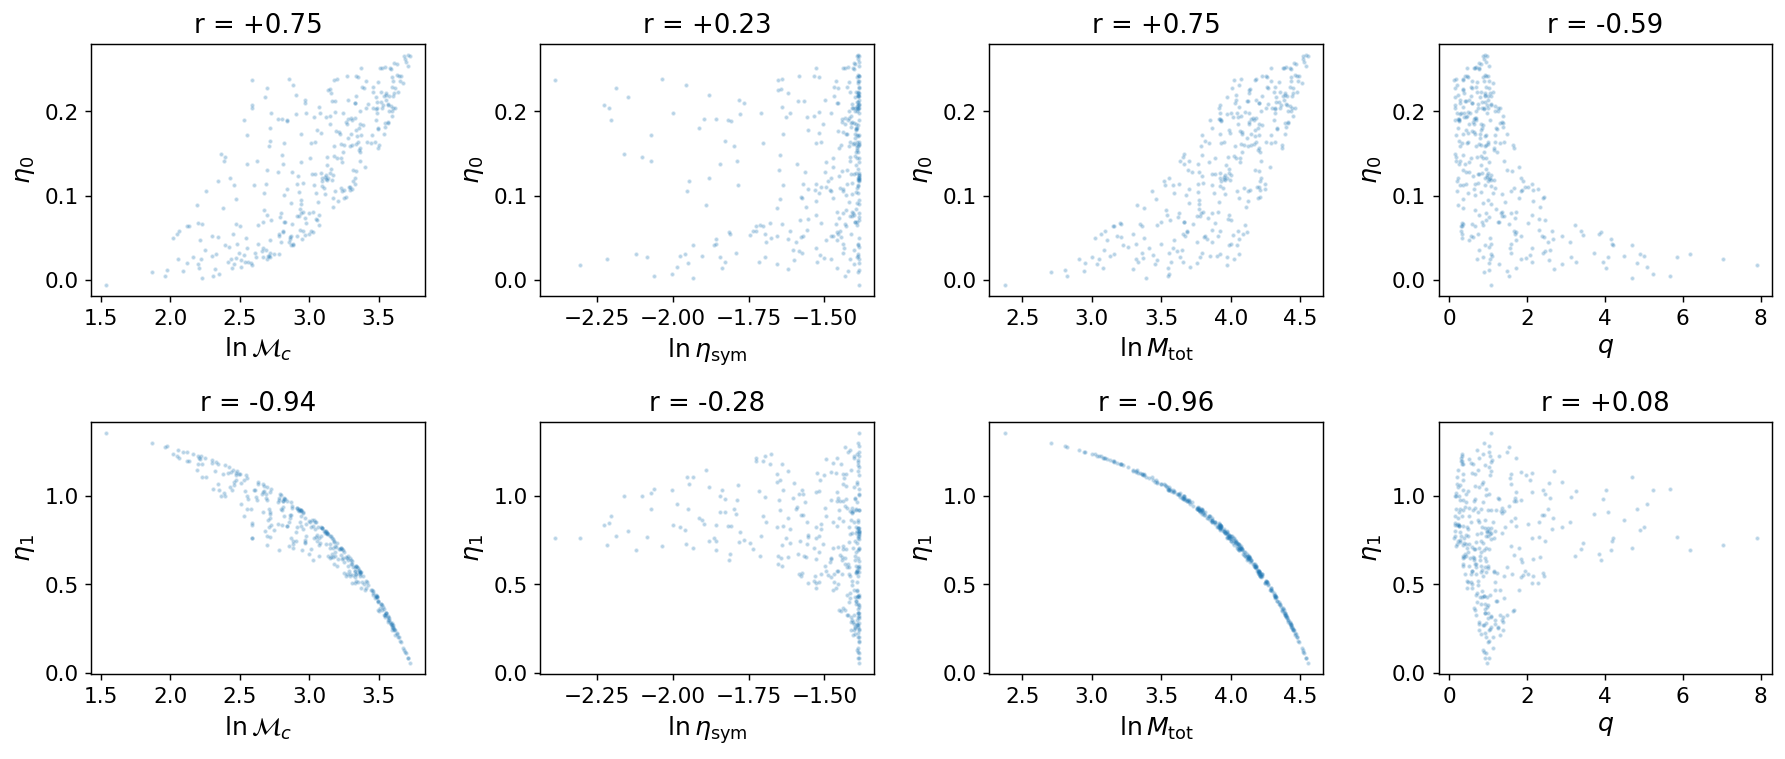

In [38]:
from scipy.stats import pearsonr

phys_test = scaler.inverse_transform(X_test)
m1_t, m2_t = phys_test[:, 0], phys_test[:, 1]
y_eval = np.asarray(get_y_sr(pruned_exprs, jnp.array(X_test)))

physics = {
    r"$\ln\mathcal{M}_c$":   np.log(chirp_mass(m1_t, m2_t)),
    r"$\ln\eta_{\rm sym}$":  np.log(symmetric_mass_ratio(m1_t, m2_t)),
    r"$\ln M_{\rm tot}$":     np.log(m1_t + m2_t),
    r"$q$":                  m2_t / m1_t,
}

fig, axes = plt.subplots(n_params, len(physics),
                         figsize=(3.5 * len(physics), 3.0 * n_params),
                         squeeze=False)
for j, (lab, p) in enumerate(physics.items()):
    for i in range(n_params):
        ax = axes[i, j]
        r, _ = pearsonr(y_eval[:, i], p)
        ax.scatter(p[::3], y_eval[::3, i], s=2, alpha=0.2)
        ax.set(xlabel=lab, ylabel=fr"$\eta_{i}$",
               title=f"r = {r:+.2f}")
plt.tight_layout()
plt.savefig("imr_eta_vs_physics.pdf")
plt.show()


## 10. Save artifacts

In [ ]:
import pickle, os
os.makedirs("sr_results_imr", exist_ok=True)
with open("sr_results_imr/sr_expressions.pkl", "wb") as f:
    pickle.dump({
        "mdl_coords":      mdl_coords,
        "frob_coords":     frob_coords,
        "pruned_exprs":    pruned_exprs,
        "physical_exprs":  [str(e) for e in physical_exprs],
        "inv_coords":      inv["inv_coords"],
        "scaler_scale":    scaler.scale_,
        "scaler_min":      scaler.min_,
        "scaler_data_min": scaler.data_min_,
        "scaler_data_max": scaler.data_max_,
    }, f)
print("saved sr_results_imr/sr_expressions.pkl")
